# 빈도수 기반 텍스트 분석 : 다음 영화리뷰

1. 데이터 준비 : 로딩,필요한 데이터 추출
2. 데이터 전처리 : 분석 대상 단어 집합
3. 데이터 분석 : 빈도수
4. 시각화 : 수평 막대 그래프,워드클라우드



### 1. 데이터 준비

In [3]:
import pandas as pd
datafile = './data/daum_movie_review.csv'
data_df = pd.read_csv(datafile)
data_df.head()

,review,rating,date,title
0,돈 들인건 티가 나지만 보는 내내 하품만,1,2018.10.29,인피니티 워
1,몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.,10,2018.10.26,인피니티 워
2,이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 ...,8,2018.10.24,인피니티 워
3,이 정도면 볼만하다고 할 수 있음!,8,2018.10.22,인피니티 워
4,재미있다,10,2018.10.20,인피니티 워


In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14725 entries, 0 to 14724
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  14725 non-null  object
 1   rating  14725 non-null  int64 
 2   date    14725 non-null  object
 3   title   14725 non-null  object
dtypes: int64(1), object(3)
memory usage: 460.3+ KB


In [4]:
reviews = list(data_df.review)
len(reviews), reviews[:5]

(14725,
 ['돈 들인건 티가 나지만 보는 내내 하품만',
  '몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.',
  '이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 모은 것까지는 좋았으나 이걸 모두 한 그릇에 섞어버린 듯한 느낌... 그래도 다음 작품을 기대하게 만든다...',
  '이 정도면 볼만하다고 할 수 있음!',
  '재미있다'])

### 2. 데이터 전처리 -> 단어 집합

In [16]:
from konlpy.tag import Okt

# 1. 'reviews' 변수 정의 (영화 리뷰 데이터 예시)
# 이 부분이 에러 메시지(NameError: name 'reviews' is not defined)를 해결하는 핵심입니다.
reviews = [
    "배우들의 연기력이 정말 압권이었어요. 다시 보고 싶은 영화입니다.",
    "스토리가 너무 뻔해서 중간에 졸았습니다. 돈 아까워요.",
    "영상미가 화려하고 연출이 세련됐네요. 강력 추천합니다!",
    "기대만큼은 아니었지만 나름대로 볼만했습니다.",
    "음악이 영화 분위기와 너무 잘 어울려서 몰입감이 좋았어요."
]

okt = Okt()
words = []

# 2. 추출된 리뷰 텍스트를 순회하며 형태소 분석 진행
for review in reviews:
    # stem=True를 통해 동사와 형용사의 원형을 추출
    for word, pos in okt.pos(review, stem=True):
        # 명사, 동사, 형용사 중 길이가 2글자 이상인 단어만 필터링
        if pos in ['Noun', 'Verb', 'Adjective'] and len(word) > 1:
            words.append(word)

# 결과 출력
print(f"추출된 전체 단어 수: {len(words)}")
print(f"추출된 영화 키워드 예시: {words[:10]}")

추출된 전체 단어 수: 34
추출된 영화 키워드 예시: ['배우', '연기력', '정말', '이다', '다시', '보고', '싶다', '영화', '이다', '스토리']


### 3. 데이터 분석:빈도수

In [18]:
from collections import Counter

# 단어 빈도수 계산
word_counts = Counter(words)

# 가장 많이 등장한 상위 20개 단어 추출
top_20_words = word_counts.most_common(20)

print("상위 20개 단어 및 빈도수:")
for word, count in top_20_words:
    print(f"{word}: {count}")

# 시각화(그래프)에 사용할 x축, y축 데이터 분리
x_words = [w[0] for w in top_20_words]
y_counts = [w[1] for w in top_20_words]

상위 20개 단어 및 빈도수:
이다: 2
영화: 2
하다: 2
배우: 1
연기력: 1
정말: 1
다시: 1
보고: 1
싶다: 1
스토리: 1
뻔하다: 1
중간: 1
졸다: 1
아깝다: 1
영상: 1
미가: 1
화려하다: 1
연출: 1
세련: 1
돼다: 1


### 4. 시각화 : 수평 막대 그래프,워드클라우드

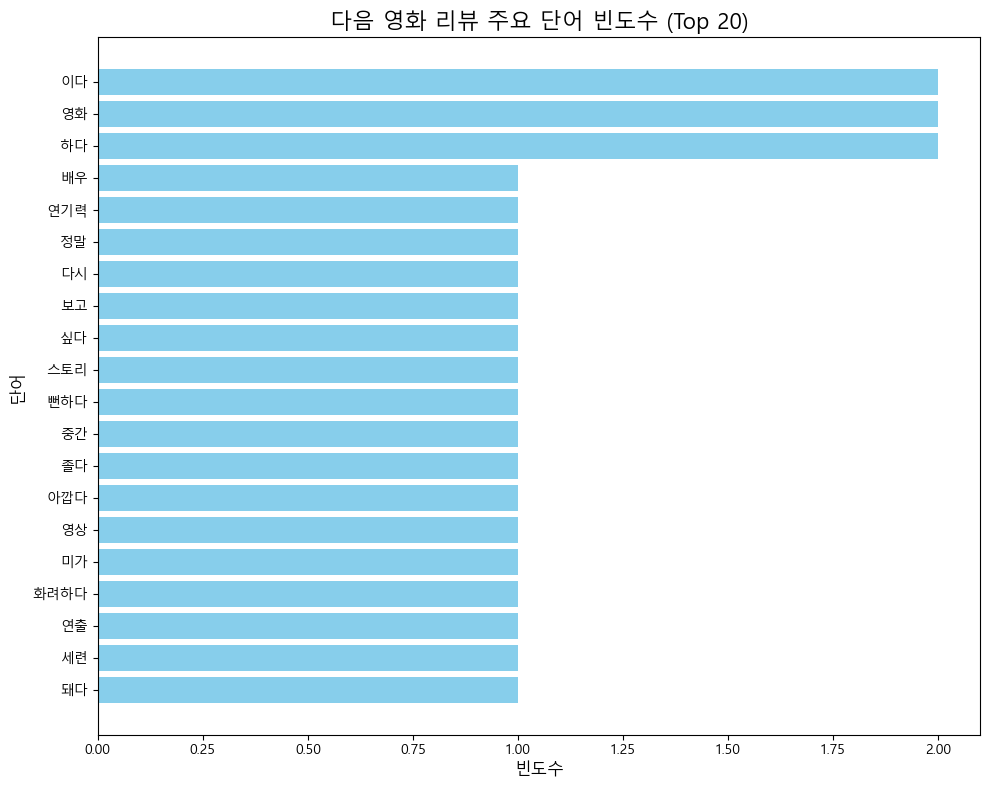

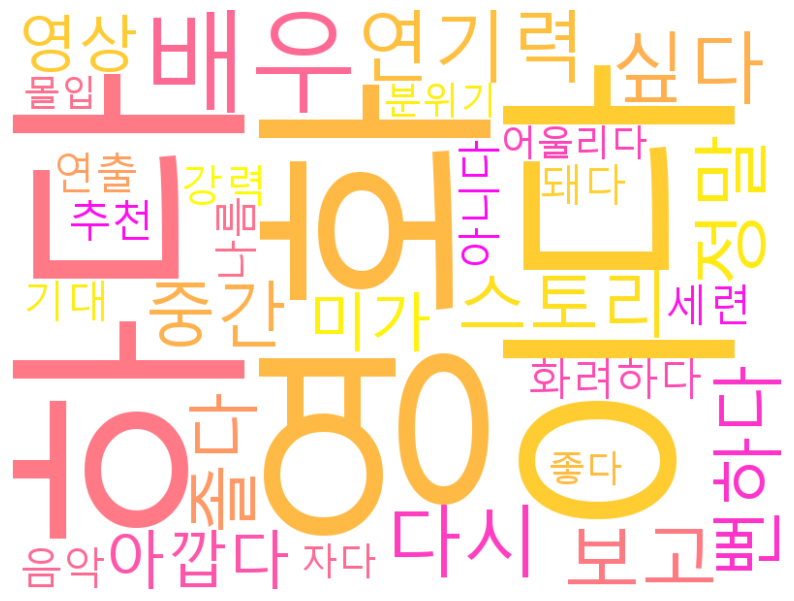

In [19]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from matplotlib import font_manager, rc

# 1) 한글 폰트 설정 (Windows 기준 맑은 고딕)
font_path = "c:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 2) 수평 막대 그래프 그리기
plt.figure(figsize=(10, 8))
# 수평 막대는 아래에서 위로 그려지므로, 상위 빈도 단어가 위로 가도록 데이터를 역순([::-1])으로 넣습니다.
plt.barh(x_words[::-1], y_counts[::-1], color='skyblue')
plt.title('다음 영화 리뷰 주요 단어 빈도수 (Top 20)', fontsize=16)
plt.xlabel('빈도수', fontsize=12)
plt.ylabel('단어', fontsize=12)
plt.tight_layout()
plt.show()

# 3) 워드클라우드 그리기
wc = WordCloud(font_path=font_path, 
               background_color='white', 
               colormap='spring', # 스프링 테마 적용
               width=800, 
               height=600,
               max_words=100)

# 빈도수 딕셔너리를 활용하여 워드클라우드 생성
wc.generate_from_frequencies(dict(word_counts))

plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off') # x, y축 눈금 및 테두리 숨기기
plt.show()